In [32]:
import yfinance as yf
import pandas as pd
import numpy as np

df=yf.download("NVDA", start="2023-01-01",multi_level_index=False)
df["Daily_Inc"]=df["Close"].pct_change()
df["Signal"]=0
df.loc[((df["Daily_Inc"].rolling(window=50).mean()>0)), "Signal"]=1
df.loc[df["Daily_Inc"].rolling(window=50).mean()<0, "Signal"]=-1

df["Signal"]=df["Signal"].shift(1)
df["Return"]=df["Signal"]*df["Daily_Inc"]

df_clean=df.dropna()
Net_return=(1+df_clean["Return"]).cumprod()
print(f"Return from my strategy: {(Net_return.iloc[-1])}")

BUY_AND_HOLD_RETURN=(1+df_clean["Daily_Inc"]).cumprod()
print(f"Return from BUY AND HOLD strategy: {BUY_AND_HOLD_RETURN.iloc[-1]}")

C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_13996\1309933438.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("NVDA", start="2023-01-01",multi_level_index=False)
[*********************100%***********************]  1 of 1 completed

Return from my strategy: 2.3265697423795832
Return from BUY AND HOLD strategy: 13.188880581870881


C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_13996\1313303571.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("QQQ", start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


Number of Gain days: 429
Number of Loss days: 345
Total days: 1504
Returns from my strategy: 0.7044227711818837



                 Close        High         Low        Open    Volume  \
Date                                                                   
2020-01-30   48.779999   48.810001   46.130001   46.490002  70460200   
2020-01-31   47.000000   48.580002   46.790001   48.400002  60322400   
2020-02-03   48.020000   48.099998   46.230000   46.400002  46983500   
2020-02-04   49.450001   49.750000   48.610001   49.209999  46302100   
2020-02-05   49.840000   50.419998   49.310001   50.290001  42737100   
...                ...         ...         ...         ...       ...   
2025-12-18  201.059998  206.360001  200.500000  203.820007  29720100   
2025-12-19  213.429993  215.179993  204.199997  204.600006  58445500   
2025-12-22  214.949997  220.169998  213.309998  220.000000  24950700   
2025-12-23  214.899994  217.029999  212.279999  212.860001  20272300   
2025-12-24  215.03999

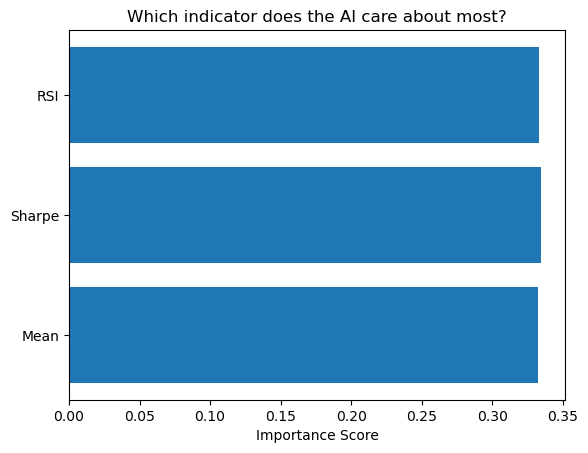

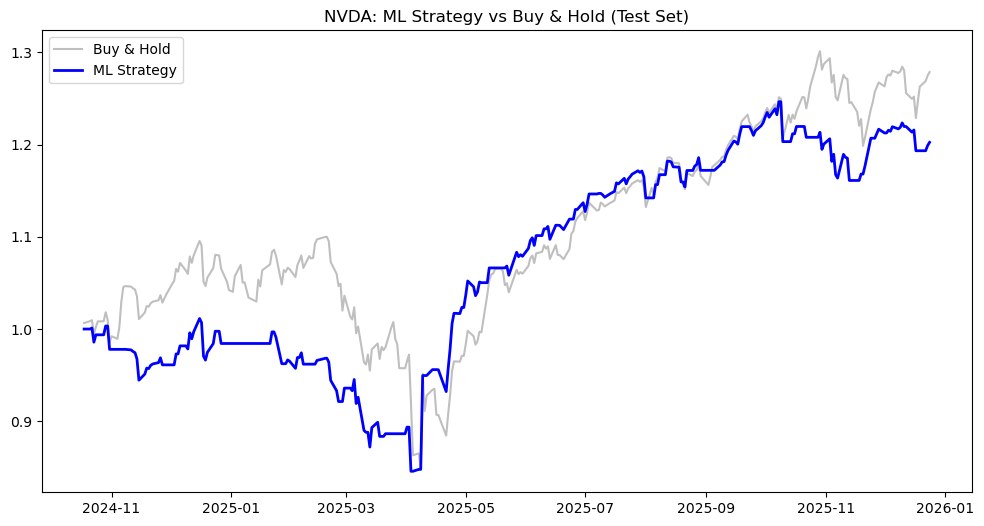

In [78]:
#Own Strategy
import yfinance as yf
import pandas as pd
import numpy as np
df=yf.download("QQQ", start="2020-01-01", multi_level_index=False)
df["Mean"]=df["Close"].rolling(window=20).mean()
df["Std"]=df["Close"].rolling(window=20).std()
df["PriceInc"]=df["Close"].pct_change()
df["Sharpe"]=1000*df["PriceInc"]/df["Std"]




df["Signal"]=0
df.loc[((df["Close"]>df["Mean"])&((df["Sharpe"]>1) | (df["Sharpe"]<-1))),"Signal"]=1
df.loc[((df["Close"]<df["Mean"])&((df["Sharpe"]>1) | (df["Sharpe"]<-1))),"Signal"]=-1
df["Signal"]=df["Signal"].shift(1)



df["Strategy_Returns"]=df["PriceInc"]*df["Signal"]


gains=(df["Strategy_Returns"]>0).sum()
loss=(df["Strategy_Returns"]<0).sum()
neutral=(df["Strategy_Returns"]==0).sum()
print(f"Number of Gain days: {gains}")
print(f"Number of Loss days: {loss}")
print(f"Total days: {len(df)}")
print(f"Returns from my strategy: {((1+df_clean["Strategy_Returns"]).cumprod()).iloc[-1]}")
print()
print()
print()
print(df_clean)

df["Target"]=(df["PriceInc"].shift(-1)>0).astype(int)
from sklearn.ensemble import RandomForestClassifier

delta=df["Close"].diff()
gain=(delta.where(delta>0,0)).rolling(window=14).mean()
loss=-1*(delta.where(delta<0,0)).rolling(window=14).mean()
rs=gain/loss
df["RSI"]=(100-100/(1+rs))
delta=df["Close"].diff()

features=["Mean","Sharpe","RSI"]
df_clean=df.dropna().copy()
X=df_clean[features]
y=df_clean['Target']


split=int(len(df_clean)*0.8)
X_train, X_test= X[:split],X[split:]
y_train, y_test= y[:split],y[split:]
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)

df_clean['ML_Signal'] = model.predict(X)
print()
print()
print()
print()
print()
df_clean["ML_returns"]=df_clean["ML_Signal"].shift(1)*df_clean["PriceInc"]
ML_returns=(1+df_clean["ML_returns"]).cumprod()

print(df_clean)
print(f"Returns using the ML model are: {ML_returns.iloc[-1]}")





test_data=df_clean.iloc[split:].copy()
test_data["ML_returns"]=test_data["ML_Signal"].shift(1)*test_data["PriceInc"]
mlresults=(1+test_data["ML_returns"]).cumprod().iloc[-1]
bhresults=(1+test_data["PriceInc"]).cumprod().iloc[-1]

print(f"ML strategy return: {mlresults}")
print(f"BH strategy return: {bhresults}")




import matplotlib.pyplot as plt

# Get the importance of each feature
importances = model.feature_importances_
feature_names = features

# Create a small bar chart
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.title("Which indicator does the AI care about most?")
plt.show()






# Calculate cumulative lines for the test set
test_data["ML_Cum"] = (1 + test_data["ML_returns"].fillna(0)).cumprod()
test_data["BH_Cum"] = (1 + test_data["PriceInc"].fillna(0)).cumprod()

# Plot them
plt.figure(figsize=(12, 6))
plt.plot(test_data["BH_Cum"], label="Buy & Hold", color="gray", alpha=0.5)
plt.plot(test_data["ML_Cum"], label="ML Strategy", color="blue", linewidth=2)
plt.title("NVDA: ML Strategy vs Buy & Hold (Test Set)")
plt.legend()
plt.show()
